<h2>Natural Languge Processing</h2>

In [12]:
#import libraries
#!pip install nltk
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tag import DefaultTagger
from nltk.stem import WordNetLemmatizer

In [2]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [13]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [16]:
data = "This Product is GREAT but  I amn't liking the colors as I am thinking they are WORST"
# 1. convert into lowercase
data = data.lower()
print("1. lowercase:",data)

# 2. tokenize
data1 = data.split()
print("2. Words using split:\n",data1)
data2 = word_tokenize(data)
print("2. Words using tokenize:\n",data2)

#3. removal of stop words
nltk_stopwords = set(stopwords.words("english"))
#print("English stopwords: ",nltk_stopwords)

for w in data2:
    if w in nltk_stopwords:
        count_w = data2.count(w)
        for words in range(count_w):
            data2.remove(w)
print("3. Words after Removal of stop words:\n",data2)

#4 Stemming: changing the word to its root form
stemm = PorterStemmer()
data3 = [stemm.stem(word) for word in data2]
print("Text after stemming:\n",data3)

# 4 POS Tagging
# https://stackoverflow.com/questions/15388831/what-are-all-possible-pos-tags-of-nltk
data_tag = nltk.pos_tag(data3)
print("After POS Tagging:\n",data_tag)

#Lemmetizer
lemm = WordNetLemmatizer()
data_lemm = [lemm.lemmatize(word) for word in data3]
print("After Lemmatizing:\n",data_lemm)

1. lowercase: this product is great but  i amn't liking the colors as i am thinking they are worst
2. Words using split:
 ['this', 'product', 'is', 'great', 'but', 'i', "amn't", 'liking', 'the', 'colors', 'as', 'i', 'am', 'thinking', 'they', 'are', 'worst']
2. Words using tokenize:
 ['this', 'product', 'is', 'great', 'but', 'i', 'am', "n't", 'liking', 'the', 'colors', 'as', 'i', 'am', 'thinking', 'they', 'are', 'worst']
3. Words after Removal of stop words:
 ['product', 'great', 'i', "n't", 'liking', 'colors', 'i', 'thinking', 'are', 'worst']
Text after stemming:
 ['product', 'great', 'i', "n't", 'like', 'color', 'i', 'think', 'are', 'worst']
After POS Tagging:
 [('product', 'NN'), ('great', 'JJ'), ('i', 'VBP'), ("n't", 'RB'), ('like', 'IN'), ('color', 'NN'), ('i', 'NN'), ('think', 'VBP'), ('are', 'VBP'), ('worst', 'JJS')]
After Lemmatizing:
 ['product', 'great', 'i', "n't", 'like', 'color', 'i', 'think', 'are', 'worst']


<h2> WORD CLOUD using WebScrapping </h2>

In [21]:
link = "https://www.geeksforgeeks.org/nlp/nlp-part-of-speech-default-tagging/"

from urllib.request import urlopen
from bs4 import BeautifulSoup

In [19]:
html_content = urlopen(link).read()
print(html_content)

b'<!DOCTYPE html><html lang="en"><head><link rel="preconnect" href="https://fonts.googleapis.com"/><link rel="preconnect" href="https://fonts.gstatic.com" crossorigin="true"/><meta charSet="UTF-8"/><meta name="viewport" content="width=device-width, initial-scale=1.0, minimum-scale=0.5, maximum-scale=3.0"/><meta name="robots" content="index, follow, max-image-preview:large, max-snippet:-1"/><link rel="shortcut icon" href="https://media.geeksforgeeks.org/wp-content/cdn-uploads/gfg_favicon.png" type="image/x-icon"/><meta name="theme-color" content="#308D46"/><meta name="image" property="og:image" content="https://media.geeksforgeeks.org/wp-content/cdn-uploads/gfg_200x200-min.png"/><meta property="og:image:type" content="image/png"/><meta property="og:image:width" content="200"/><meta property="og:image:height" content="200"/><meta name="facebook-domain-verification" content="xo7t4ve2wn3ywfkjdvwbrk01pvdond"/><meta property="og:title" content="POS(Parts-Of-Speech) Tagging in NLP - GeeksforG

In [22]:
soup = BeautifulSoup(html_content)
print(soup)

<!DOCTYPE html>
<html lang="en"><head><link href="https://fonts.googleapis.com" rel="preconnect"/><link crossorigin="true" href="https://fonts.gstatic.com" rel="preconnect"/><meta charset="utf-8"/><meta content="width=device-width, initial-scale=1.0, minimum-scale=0.5, maximum-scale=3.0" name="viewport"/><meta content="index, follow, max-image-preview:large, max-snippet:-1" name="robots"/><link href="https://media.geeksforgeeks.org/wp-content/cdn-uploads/gfg_favicon.png" rel="shortcut icon" type="image/x-icon"/><meta content="#308D46" name="theme-color"/><meta content="https://media.geeksforgeeks.org/wp-content/cdn-uploads/gfg_200x200-min.png" name="image" property="og:image"/><meta content="image/png" property="og:image:type"/><meta content="200" property="og:image:width"/><meta content="200" property="og:image:height"/><meta content="xo7t4ve2wn3ywfkjdvwbrk01pvdond" name="facebook-domain-verification"/><meta content="POS(Parts-Of-Speech) Tagging in NLP - GeeksforGeeks" property="og:ti

In [23]:
data = soup.get_text()

data = data.lower()
print("1. lowercase:",data)

# 2. tokenize
data1 = data.split()
print("2. Words using split:\n",data1)
data2 = word_tokenize(data)
print("2. Words using tokenize:\n",data2)

#3. removal of stop words
nltk_stopwords = set(stopwords.words("english"))
#print("English stopwords: ",nltk_stopwords)

for w in data2:
    if w in nltk_stopwords:
        count_w = data2.count(w)
        for words in range(count_w):
            data2.remove(w)
print("3. Words after Removal of stop words:\n",data2)

#4 Stemming: changing the word to its root form
stemm = PorterStemmer()
data3 = [stemm.stem(word) for word in data2]

1. lowercase: pos(parts-of-speech) tagging in nlp - geeksforgeekscoursestutorialspracticejobsnlp tutoriallibrariesphasestext preprosessingtokenizationlemmatizationword embeddingsprojects ideasinterview questionnlp quiznlp pipelinedl for nlpshare your experiencesintroduction to nlpintroduction to natural language processing (nlp)nlp vs nlu vs nlgapplications of nlpwhy is nlp important?phases of natural language processing (nlp)the future of natural language processing: trends and innovationslibraries for nlpnltk - nlptokenization using spacypython | tokenize text using textblobintroduction to hugging face transformersnlp gensim tutorialnlp libraries in pythontext normalization in nlpnormalizing textual data with pythonregex tutorial - how to write regular expressionstokenization in nlplemmatization with nltkintroduction to stemmingremoving stop words with nltk in pythonpos(parts-of-speech) tagging in nlptext representation and embedding techniquesone-hot encoding in nlpbag of words (bow

In [25]:
!pip install wordcloud


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


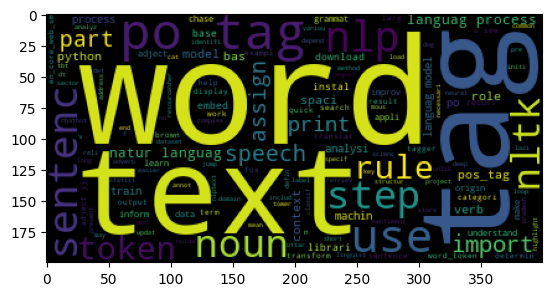

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(max_words = 200).generate(" ".join(data3))
plt.imshow(wc)
plt.show()

<h2> SENTIMENT ANALYSIS in NLP</h2>

Dataset : https://github.com/swapnilsaurav/Dataset/blob/master/amazon.csv


In [33]:
import numpy as np
import pandas as pd
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tag import DefaultTagger
from nltk.stem import WordNetLemmatizer

# Sentiment analysis
from nltk.sentiment.vader import SentimentIntensityAnalyzer


In [32]:
link = "https://raw.githubusercontent.com/swapnilsaurav/Dataset/refs/heads/master/amazon.csv"
df = pd.read_csv(link)
print(link)

https://raw.githubusercontent.com/swapnilsaurav/Dataset/refs/heads/master/amazon.csv


In [34]:
def process_text(data):
    data = data.lower()
    # 2. tokenize
    data2 = word_tokenize(data)
    #3. removal of stop words
    nltk_stopwords = set(stopwords.words("english"))
    for w in data2:
        if w in nltk_stopwords:
            count_w = data2.count(w)
            for words in range(count_w):
                data2.remove(w)

    lemm = WordNetLemmatizer()
    data_lemm = [lemm.lemmatize(word) for word in data2]
    text_out = " ".join(data2)
    return text_out

In [35]:

# read each line from the review text and send it to the function to process each line of review
df["Outtext"] = df["reviewText"].apply(process_text)

#now run sentiment analyzer model
analyzer = SentimentIntensityAnalyzer()


# function to read each line and return the intensity value
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    sentiment = 1 if scores['pos']>0 else 0
    return sentiment

df['Sentiment']= df['Outtext'].apply(get_sentiment)
print(df.head())

                                          reviewText  Positive  \
0  This is a one of the best apps acording to a b...         1   
1  This is a pretty good version of the game for ...         1   
2  this is a really cool game. there are a bunch ...         1   
3  This is a silly game and can be frustrating, b...         1   
4  This is a terrific game on any pad. Hrs of fun...         1   

                                             Outtext  Sentiment  
0  is one the best apps acording bunch people i a...          1  
1  is pretty good version the game being free . a...          1  
2  is really cool game . are bunch levels you fin...          1  
3  is silly game can frustrating , lots fun defin...          1  
4  is terrific game any pad . hrs fun . grandkids...          1  


In [37]:
#Evaluate Our analysis
from sklearn.metrics import confusion_matrix, accuracy_score
print("Accuracy Score: ",accuracy_score(df['Sentiment'],df['Positive']))
print("Confusion Matrix: \n",confusion_matrix(df['Sentiment'],df['Positive']))

Accuracy Score:  0.79185
Confusion Matrix: 
 [[ 1201   597]
 [ 3566 14636]]
